2104 creativity data including RAT, AUT scores as well as eye blink rate and WMC (ospan) scores. AUT data consist of originality, flexibility, fluency scores. RAT include accuracy as well as insight (likert scale) scores. Participants went through all tests at baseline, during placebo and 10 mg psilocybin. Main outcomes are difference scores from baseline (i.e. AUT during placebo - baseline)

We use EBR as an individual variability measure for creativity as in: https://www.sciencedirect.com/science/article/pii/S0010027710000715?via%3Dihub


First read the data and z-score all continous variables.

In [1]:
df <- read.csv("/Users/zsayali1/Documents/2104_Creativity/EBRWMC_Updated.csv")
df[df == 999] <- NA
df$Dose <- factor(df$Dose)
df$Dose <- relevel(df$Dose, ref = "Baseline")
df$Session <- factor(df$Session)
df$`Participant.ID` <- factor(df$`Participant.ID`)
vars_to_scale <- setdiff(names(df), c("Participant.ID", "Dose", "Session"))
df[vars_to_scale] <- scale(df[vars_to_scale]) # zscore continous variables
summary(df)


 Participant.ID        Dose    Session  RAT_Accuracy       RAT_Accurate_Insight
 5      : 3     Baseline :30   1:30    Min.   :-3.065511   Min.   :-4.8446     
 10     : 3     10mg/70kg:30   2:30    1st Qu.:-0.503722   1st Qu.:-0.3007     
 12     : 3     Placebo  :30   3:30    Median : 0.008635   Median : 0.1365     
 16     : 3                            Mean   : 0.000000   Mean   : 0.0000     
 17     : 3                            3rd Qu.: 0.520993   3rd Qu.: 0.5765     
 18     : 3                            Max.   : 2.314245   Max.   : 1.6124     
 (Other):72                            NA's   :1           NA's   :4           
 RAT_Inaccurate_Insight RAT_N.A_Insight    AUT_Originality    AUT_Fluency     
 Min.   :-1.9826        Min.   :-1.66823   Min.   :-3.6275   Min.   :-1.4877  
 1st Qu.:-0.5402        1st Qu.:-0.67383   1st Qu.:-0.5187   1st Qu.:-0.7095  
 Median : 0.1810        Median :-0.07938   Median : 0.0657   Median :-0.1259  
 Mean   : 0.0000        Mean   : 0.00000   M

First, we check the variability of eye blinks across experimental phases and don't see a difference

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


[1] 30


FALSE 
   90 

[1] 5  5  5  10 10 10 12 12 12 16 16 16 17 17 17 18 18 18 19 19
30 Levels: 5 10 12 16 17 18 19 21 30 33 35 36 40 42 45 46 47 52 53 57 60 ... 91

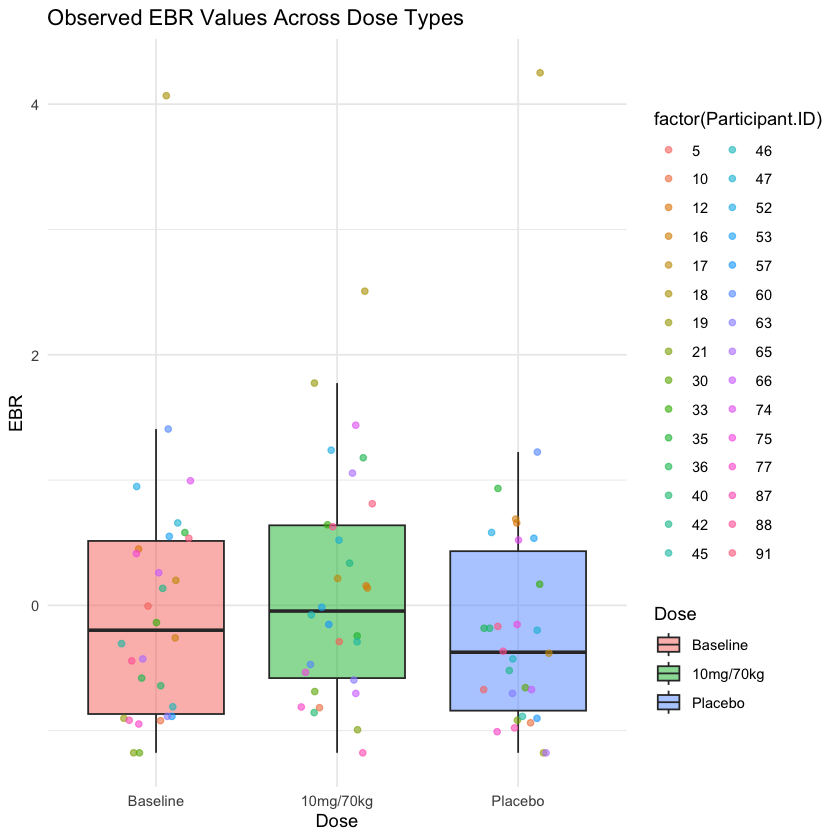

In [3]:
library(ggplot2)
library(ggpubr)
dplyr::n_distinct(df$Participant.ID)
table(is.na(df$Participant.ID))
head(df$Participant.ID, 20)

ggplot(df, aes(x = Dose, y = EBR)) +
  geom_boxplot(aes(fill = Dose), outlier.shape = NA, alpha = 0.5) +
  geom_jitter(aes(color = factor(Participant.ID)),
              width = 0.2, size = 1.5, alpha = 0.6) +
  labs(title = "Observed EBR Values Across Dose Types",
       x = "Dose", y = "EBR") +
  theme_minimal()

Then, we look at the relationship between eye blink rate and AUT originality, as was reported in the literature (is it an inverted U shape function?). We indeed see an inverted U shape relationship between EBR and AUT originality, however, note the outlier

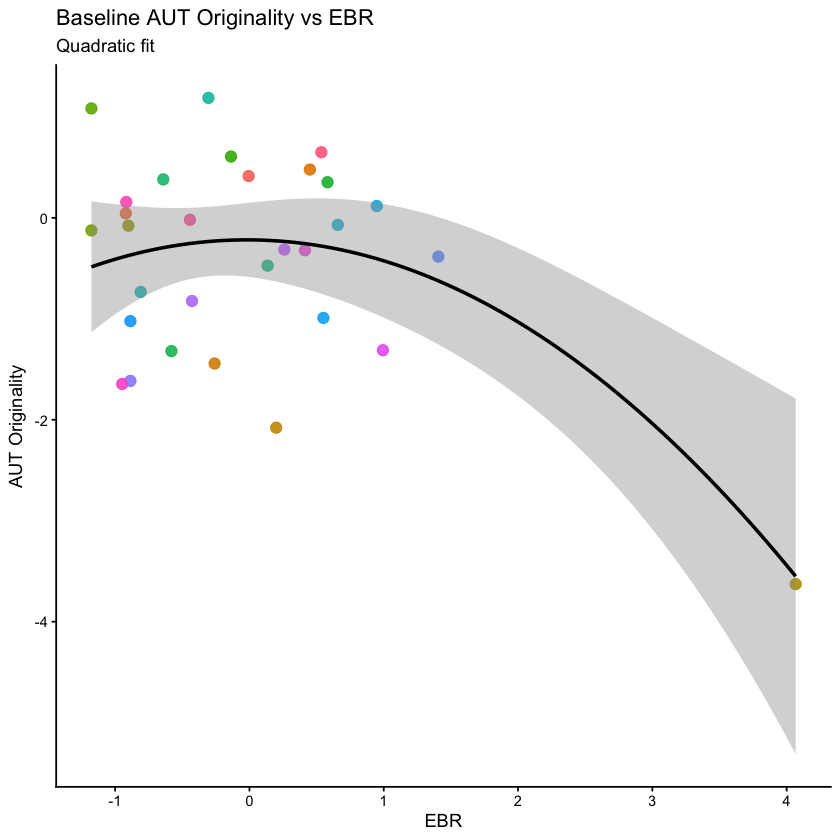

In [11]:
library(dplyr)
df_baseline <- df %>%
  filter(Dose == "Baseline") %>%
  select(Participant.ID, EBR, WMC, AUT_Originality) %>%
  na.omit()
ggplot(df_baseline, aes(x = EBR, y = AUT_Originality)) +
  geom_point(aes(color = Participant.ID), size = 2.8, alpha = 0.9) +
  stat_smooth(
    method = "lm",
    formula = y ~ x + I(x^2),
    se = TRUE,
    color = "black",
    linewidth = 1
  ) +
  labs(
    title = "Baseline AUT Originality vs EBR",
    subtitle = "Quadratic fit",
    x = "EBR",
    y = "AUT Originality"
  ) +
  theme_classic() +
  theme(legend.position = "none")

So, we identify the outliers in the data

In [12]:
df_baseline <- df %>%
  filter(Dose == "Baseline") %>%
  select(Participant.ID, EBR, WMC, AUT_Originality) %>%
  na.omit()

m_quad <- lm(AUT_Originality ~ EBR + I(EBR^2) + WMC, data = df_baseline)

df_baseline$cooks_d <- cooks.distance(m_quad)
df_baseline$hat <- hatvalues(m_quad)
df_baseline$std_resid <- rstandard(m_quad)

df_baseline %>%
  arrange(desc(cooks_d)) %>%
  head()

,Participant.ID,EBR,WMC,AUT_Originality,cooks_d,hat,std_resid
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18,4.0671039,0.7370099,-3.62751458,3.04517570,0.97612934,-0.5457764
2,77,-0.9473530,1.4832563,-1.64548229,0.19064694,0.18501940,-1.8327782
3,30,-1.1766725,-1.0050073,1.08380164,0.18855866,0.15210765,2.0504447
4,10,-0.9203742,-2.7767314,0.04432541,0.11377264,0.31454568,0.9958555
5,63,-0.8862011,0.8142433,-1.61503003,0.08448935,0.11061262,-1.6484437
6,17,0.1992447,-0.6734774,-2.07854859,0.08190626,0.06983198,-2.0890175


In the absence of the outliers, the quadratic trend is not present but this may be an overkill - we should discuss

Participant.ID,EBR,AUT_Originality,cooks_d,hat,std_resid,influential
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
18,4.067103922,-3.62751458,3.045176e+00,0.97612934,-0.54577635,TRUE
77,-0.947352967,-1.64548229,1.906469e-01,0.18501940,-1.83277821,TRUE
30,-1.176672502,1.08380164,1.885587e-01,0.15210765,2.05044473,TRUE
10,-0.920374198,0.04432541,1.137726e-01,0.31454568,0.99585547,FALSE
63,-0.886201091,-1.61503003,8.448935e-02,0.11061262,-1.64844373,FALSE
17,0.199244708,-2.07854859,8.190626e-02,0.06983198,-2.08901747,FALSE
36,-0.580441711,-1.31958453,3.868542e-02,0.12185476,-1.05600405,FALSE
74,0.994219096,-1.31138585,3.014181e-02,0.10351253,-1.02185748,FALSE
45,-0.305258269,1.18833488,2.867595e-02,0.04259969,1.60558190,FALSE



Call:
lm(formula = AUT_Originality ~ EBR + I(EBR^2) + WMC, data = df_baseline)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7667 -0.5680  0.1635  0.5807  1.6556 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept) -0.21940    0.18101  -1.212   0.2364  
EBR         -0.03305    0.22350  -0.148   0.8836  
I(EBR^2)    -0.19860    0.07817  -2.541   0.0174 *
WMC          0.11577    0.16472   0.703   0.4884  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8769 on 26 degrees of freedom
Multiple R-squared:  0.349,	Adjusted R-squared:  0.2738 
F-statistic: 4.645 on 3 and 26 DF,  p-value: 0.009921



Call:
lm(formula = AUT_Originality ~ EBR + I(EBR^2) + WMC, data = df_baseline_no_outlier)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.6950 -0.5265  0.0563  0.5878  1.5330 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.307306   0.245679  -1.251    0.223
EBR          0.001994   0.235785   0.008    0.993
I(EBR^2)    -0.018969   0.342999  -0.055    0.956
WMC          0.112692   0.167111   0.674    0.506

Residual standard error: 0.8891 on 25 degrees of freedom
Multiple R-squared:  0.01853,	Adjusted R-squared:  -0.09925 
F-statistic: 0.1573 on 3 and 25 DF,  p-value: 0.924


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
EBR,1,0.012575721,0.012575721,0.015908006,0.9006403
I(EBR^2),1,0.001006182,0.001006182,0.001272798,0.9718238
WMC,1,0.359492925,0.359492925,0.454750514,0.5062760
Residuals,25,19.763195090,0.790527804,NA,NA


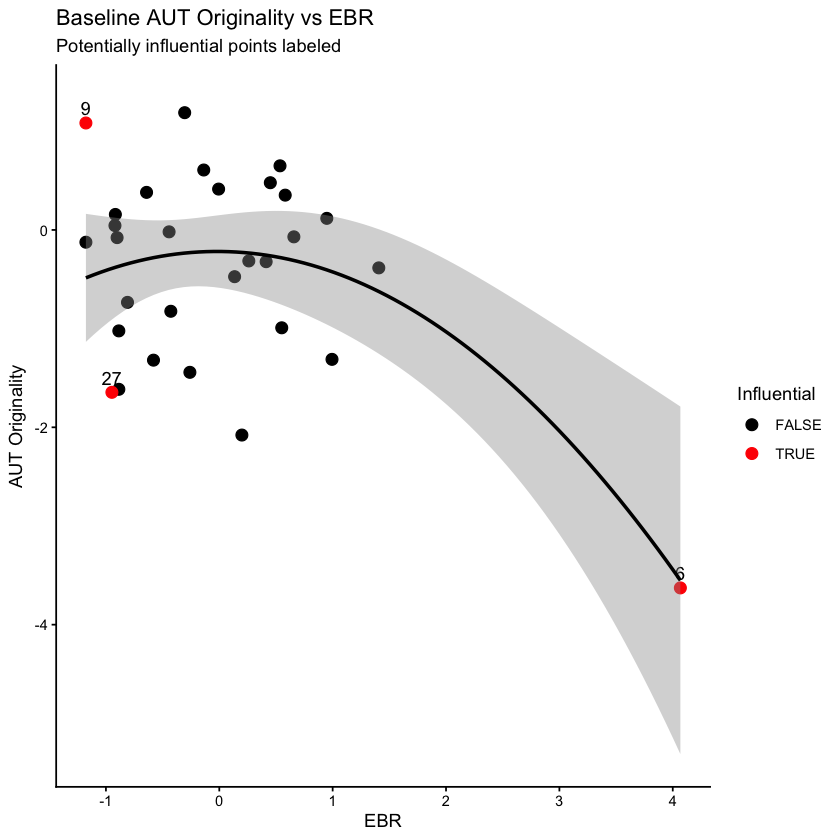

In [13]:
cutoff <- 4 / nrow(df_baseline)

df_baseline %>%
  mutate(influential = cooks_d > cutoff) %>%
  select(Participant.ID, EBR, AUT_Originality, cooks_d, hat, std_resid, influential) %>%
  arrange(desc(cooks_d))

library(ggplot2)

ggplot(df_baseline, aes(x = EBR, y = AUT_Originality)) +
  geom_point(aes(color = cooks_d > cutoff), size = 3) +
  geom_text(
    aes(label = ifelse(cooks_d > cutoff, Participant.ID, "")),
    nudge_y = 0.15,
    show.legend = FALSE
  ) +
  stat_smooth(
    method = "lm",
    formula = y ~ x + I(x^2),
    se = TRUE,
    color = "black",
    linewidth = 1
  ) +
  scale_color_manual(values = c("black", "red")) +
  labs(
    title = "Baseline AUT Originality vs EBR",
    subtitle = "Potentially influential points labeled",
    x = "EBR",
    y = "AUT Originality",
    color = "Influential"
  ) +
  theme_classic()

infl_id <- df_baseline %>%
  slice_max(cooks_d, n = 1) %>%
  pull(Participant.ID)

df_baseline_no_outlier <- df_baseline %>%
  filter(Participant.ID != infl_id)

m_quad_no_outlier <- lm(AUT_Originality ~ EBR + I(EBR^2) + WMC, data = df_baseline_no_outlier)

summary(m_quad)
summary(m_quad_no_outlier)
anova(m_quad_no_outlier)

Next, we look at baseline measures overall in relation to EBR and WMC. We see some expected trends here such as in RAT accuracy and WMC but not reaching significance. 

In [14]:
run_baseline_analysis <- function(data, outcome, id_var = "Participant.ID") {
  
  dat <- data %>%
    filter(Dose == "Baseline") %>%
    select(all_of(c(id_var, "EBR", "WMC", outcome))) %>%
    na.omit()
  
  colnames(dat)[colnames(dat) == outcome] <- "y"
  
  model <- lm(y ~ EBR + WMC, data = dat)
  
  p_ebr <- ggplot(dat, aes(x = EBR, y = y)) +
    geom_point(aes(color = .data[[id_var]]), size = 2.5, alpha = 0.9) +
    geom_smooth(method = "lm", se = TRUE, color = "black") +
    labs(
      title = paste("Baseline", outcome, "vs EBR"),
      x = "EBR",
      y = outcome
    ) +
    theme_classic() +
    theme(legend.position = "none")
  
  p_wmc <- ggplot(dat, aes(x = WMC, y = y)) +
    geom_point(aes(color = .data[[id_var]]), size = 2.5, alpha = 0.9) +
    geom_smooth(method = "lm", se = TRUE, color = "black") +
    labs(
      title = paste("Baseline", outcome, "vs WMC"),
      x = "WMC",
      y = outcome
    ) +
    theme_classic() +
    theme(legend.position = "none")
  
  list(
    data = dat,
    model = model,
    summary = summary(model),
    anova = anova(model),
    plot_ebr = p_ebr,
    plot_wmc = p_wmc
  )
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


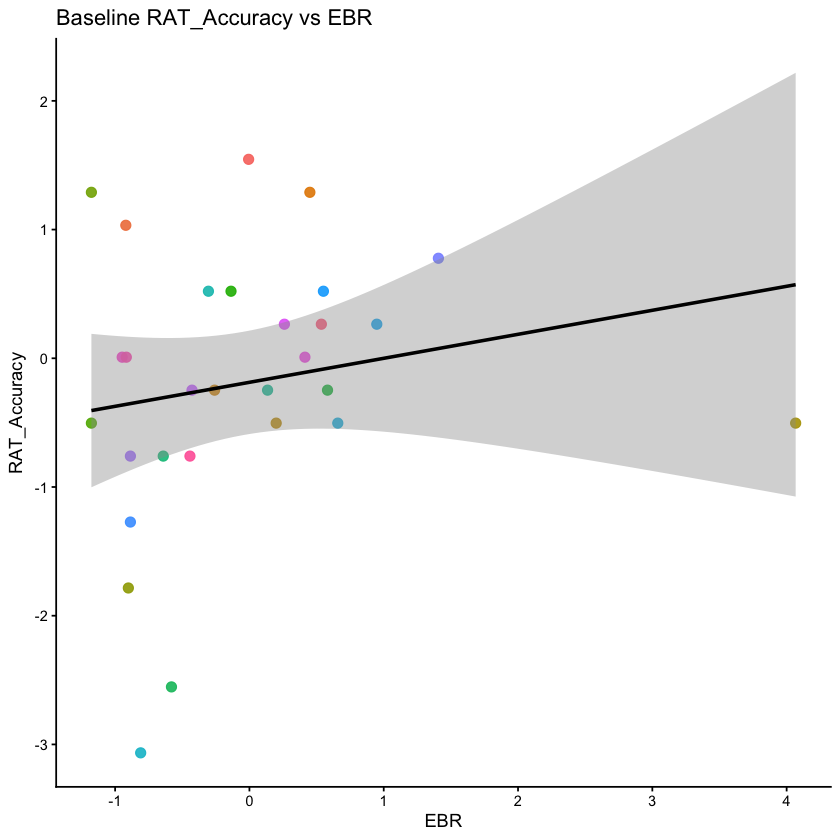

`geom_smooth()` using formula = 'y ~ x'


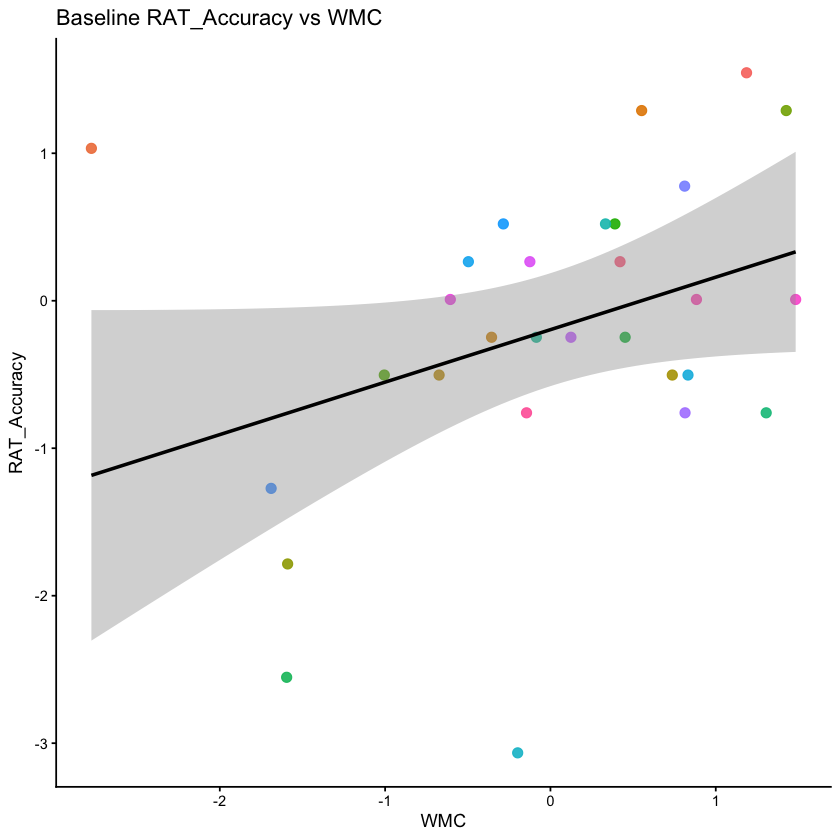

`geom_smooth()` using formula = 'y ~ x'


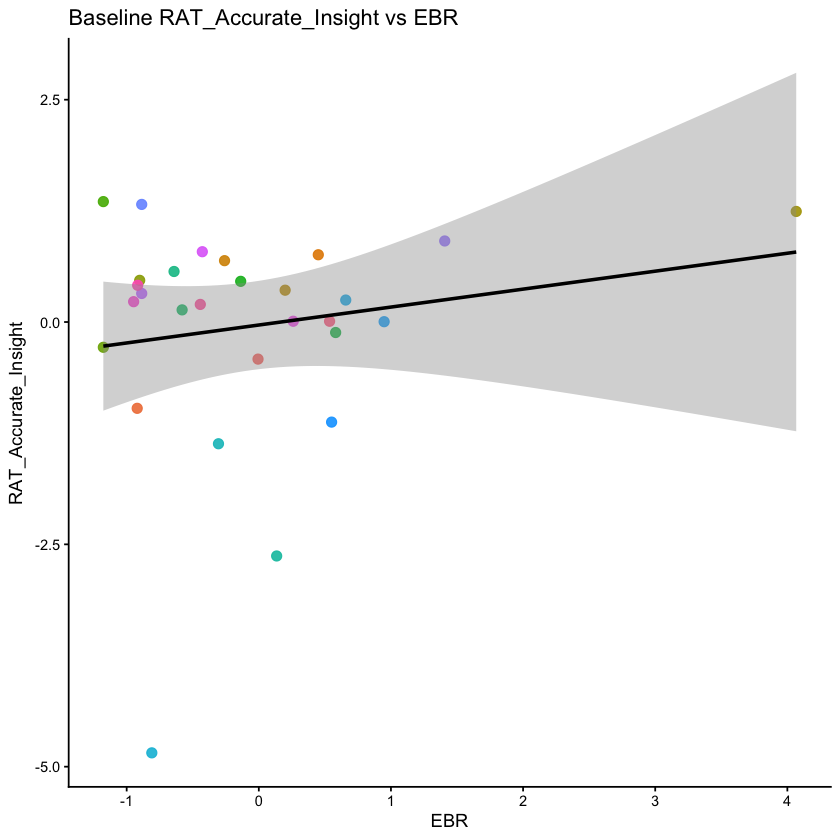

`geom_smooth()` using formula = 'y ~ x'


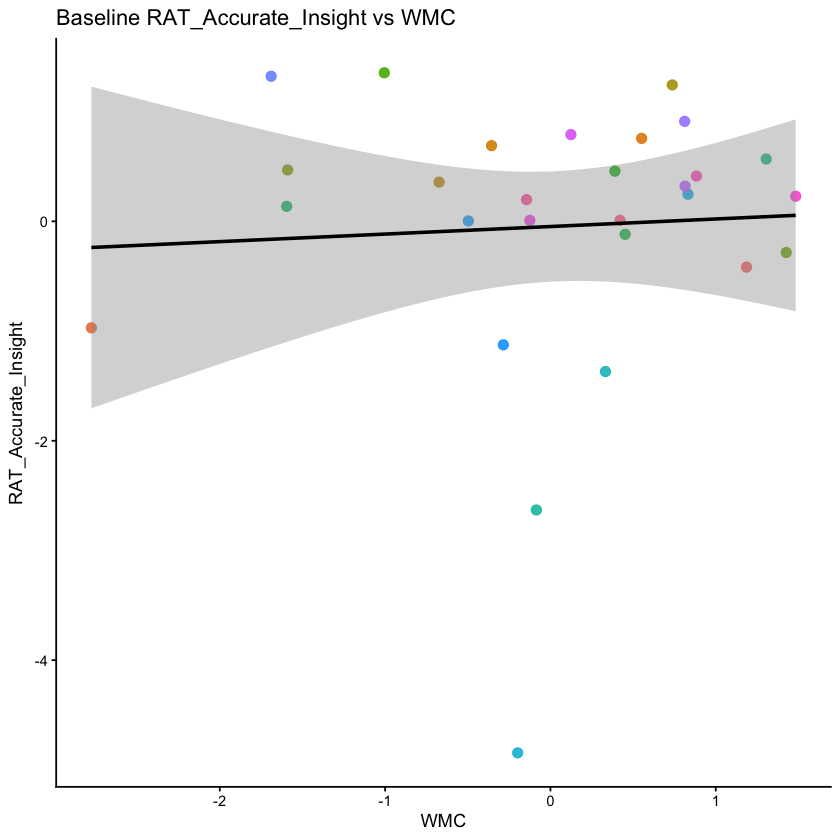

`geom_smooth()` using formula = 'y ~ x'


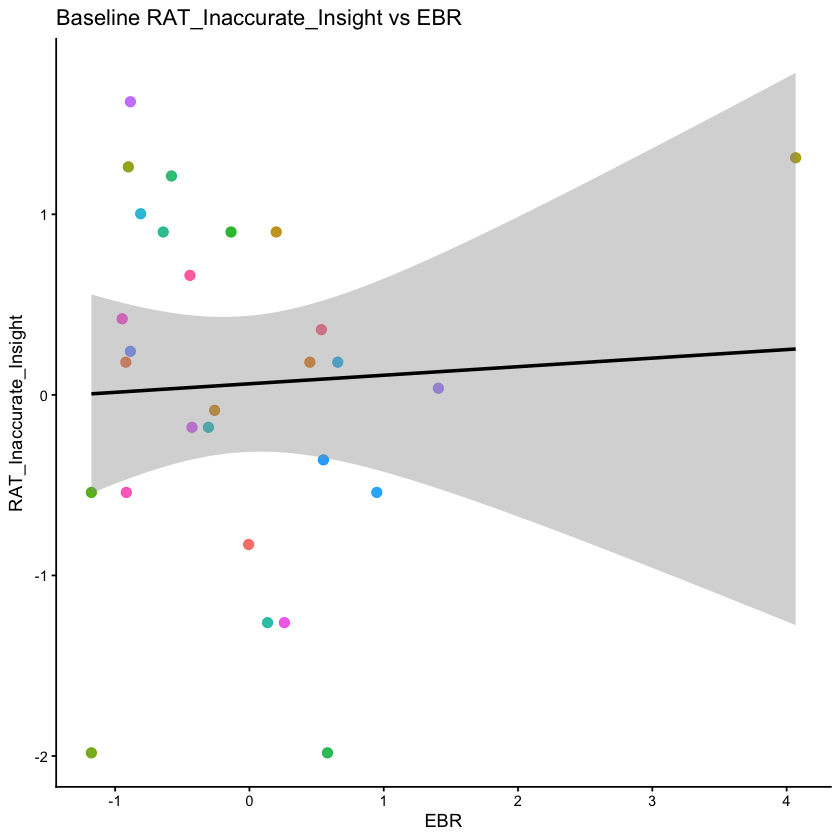

`geom_smooth()` using formula = 'y ~ x'


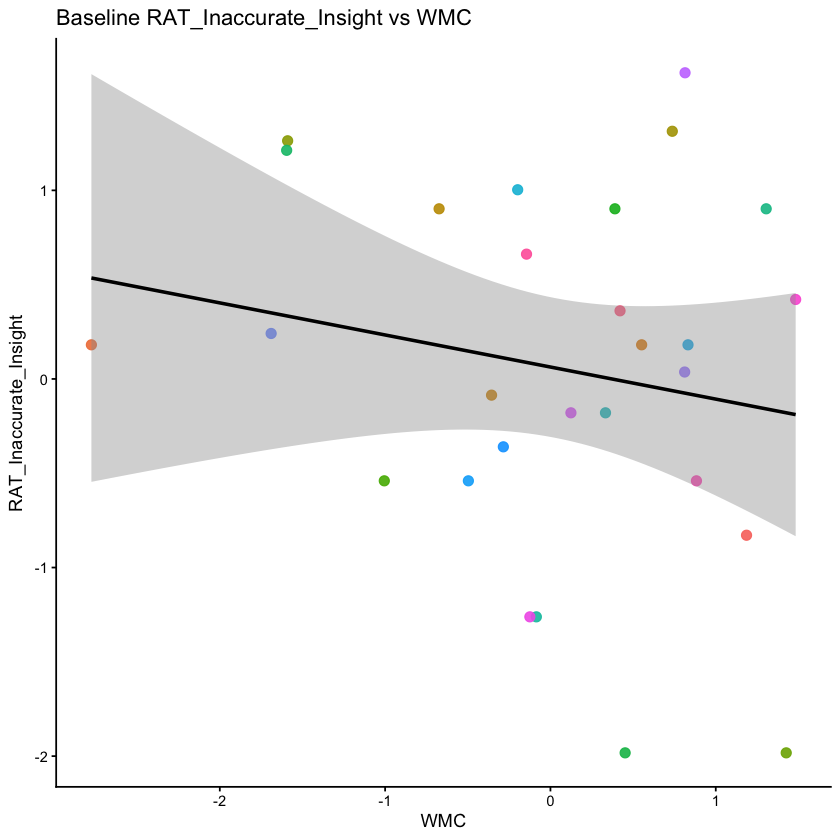

`geom_smooth()` using formula = 'y ~ x'


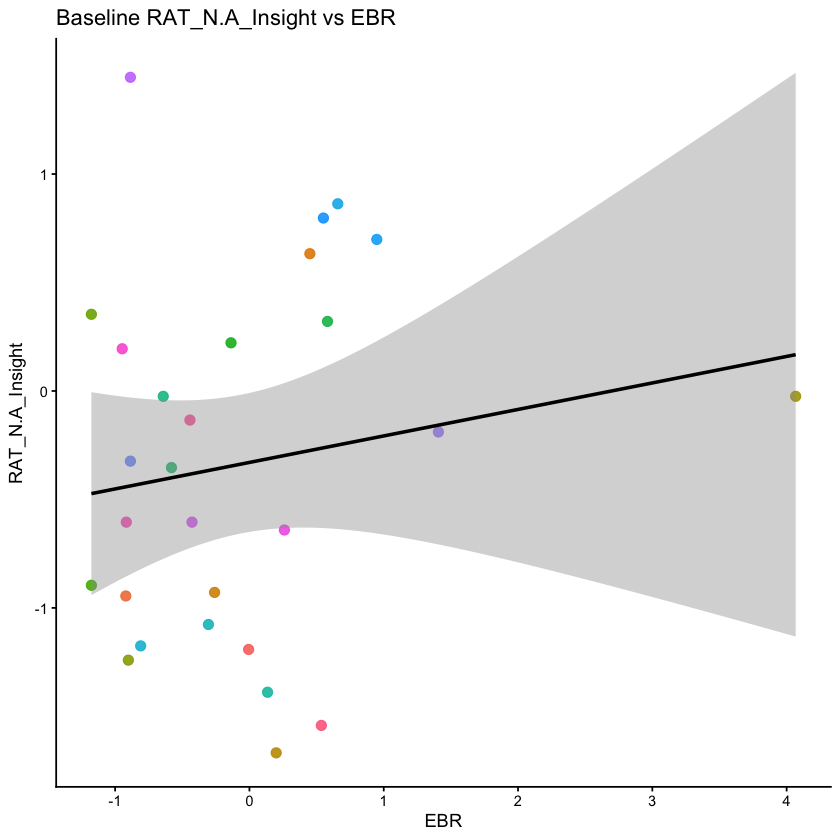

`geom_smooth()` using formula = 'y ~ x'


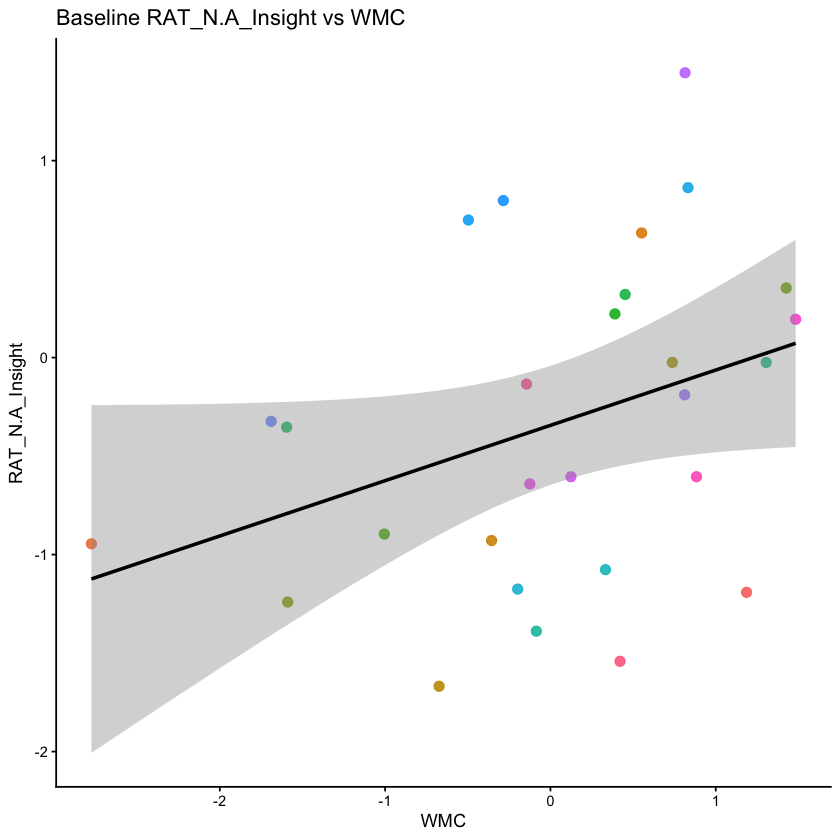

`geom_smooth()` using formula = 'y ~ x'


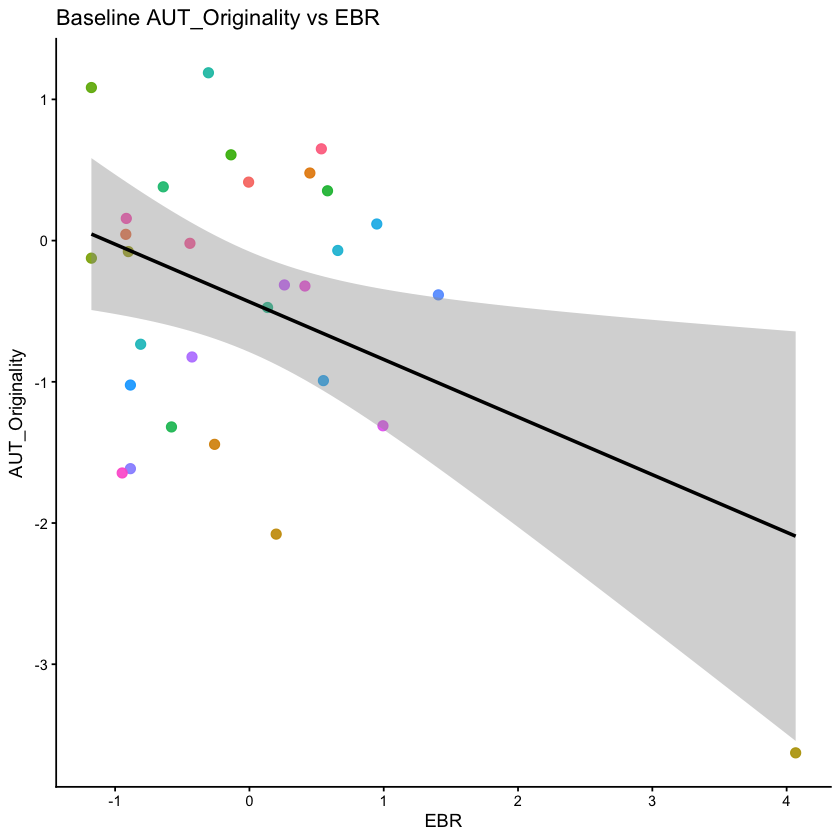

`geom_smooth()` using formula = 'y ~ x'


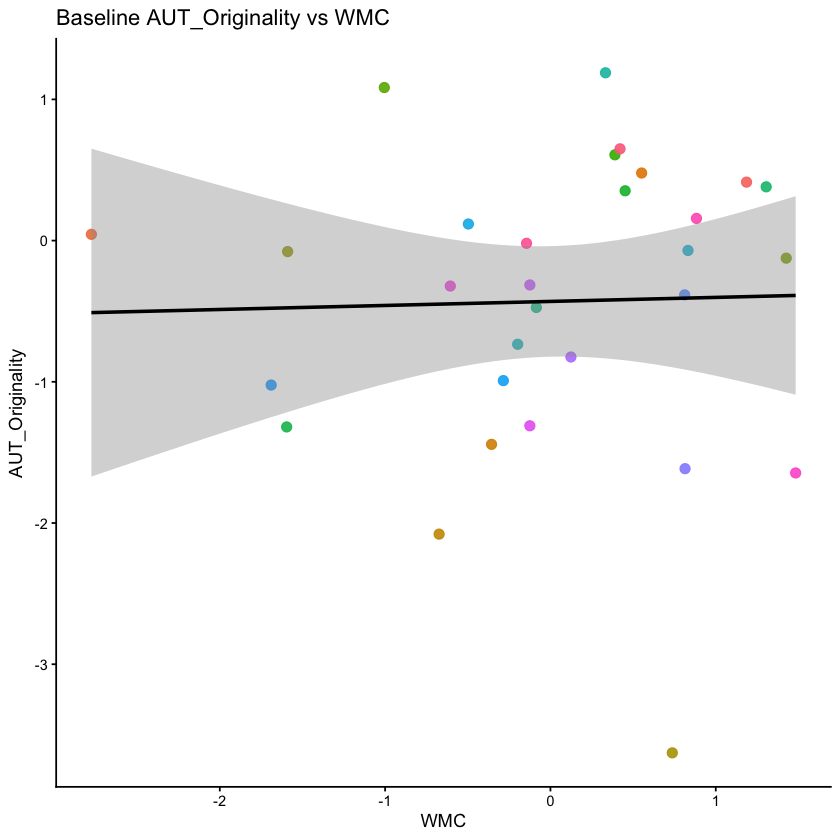

`geom_smooth()` using formula = 'y ~ x'


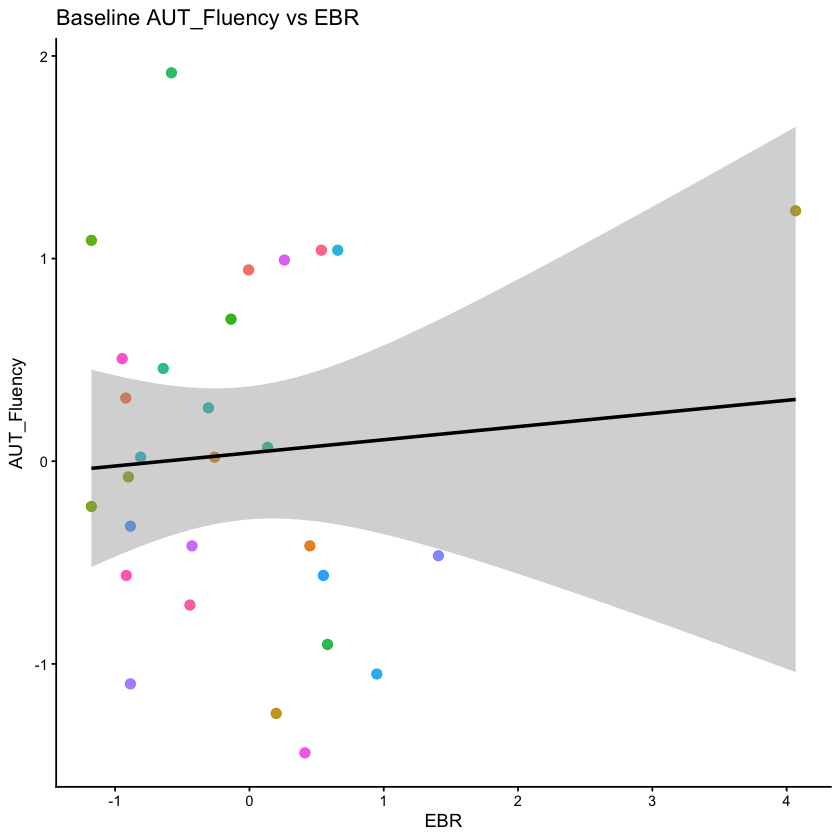

`geom_smooth()` using formula = 'y ~ x'


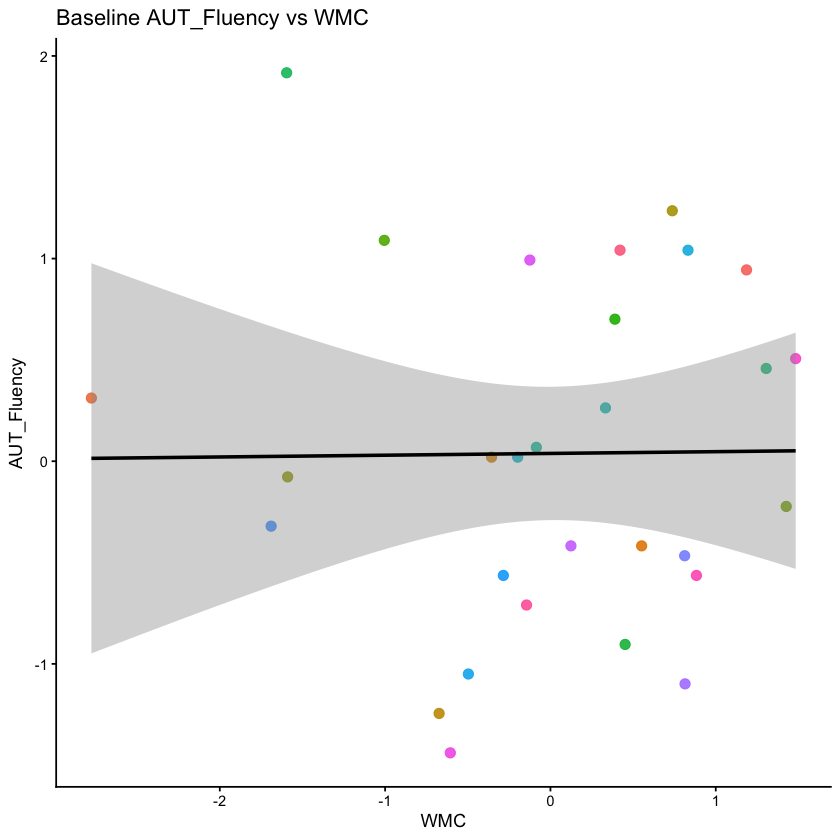

`geom_smooth()` using formula = 'y ~ x'


$RAT_Accuracy
$RAT_Accuracy$data
   Participant.ID          EBR         WMC            y
1               5 -0.005965438  1.18617941  1.545708523
2              10 -0.920374198 -2.77673140  1.033350763
3              12  0.450102542  0.55163837  1.289529643
4              16 -0.259394362 -0.35620686 -0.247543637
5              17  0.199244708 -0.67347738 -0.503722517
6              18  4.067103922  0.73700991 -0.503722517
7              19 -0.901489060 -1.58964057 -1.784616917
8              21 -1.176672502  1.42621179  1.289529643
9              30 -1.176672502 -1.00500725 -0.503722517
10             33 -0.137090610  0.39003241  0.520993003
11             35  0.581443933  0.45182293 -0.247543637
12             36 -0.580441711 -1.59558197 -2.553153557
13             40 -0.641593587  1.30500733 -0.759901397
14             42  0.135120737 -0.08527923 -0.247543637
15             45 -0.305258269  0.33299502  0.520993003
16             46 -0.809761246 -0.19816574 -3.065511317
17             

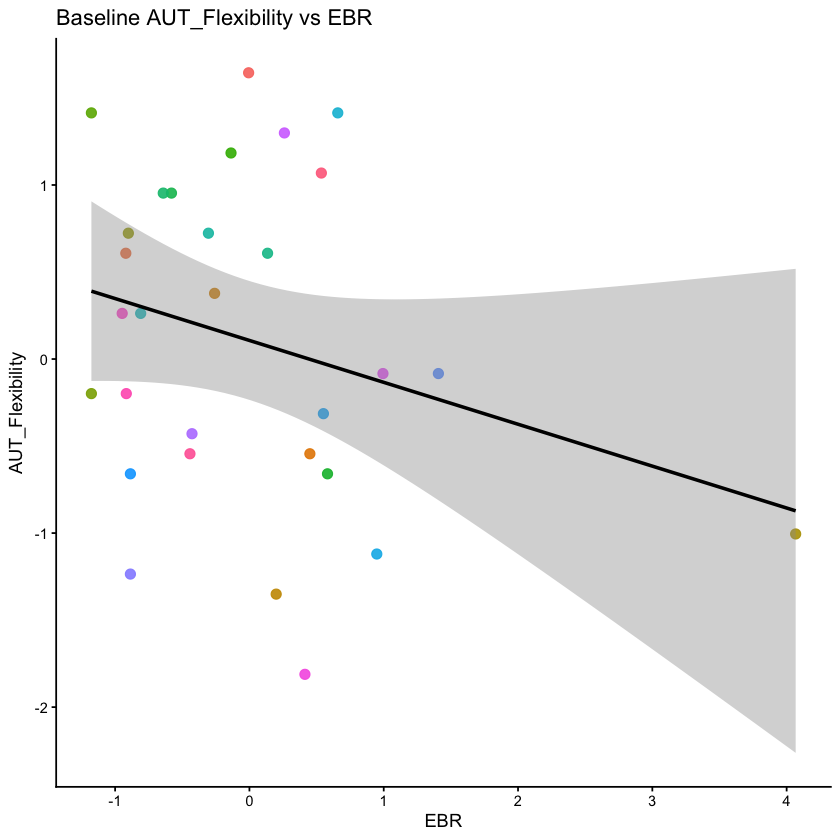

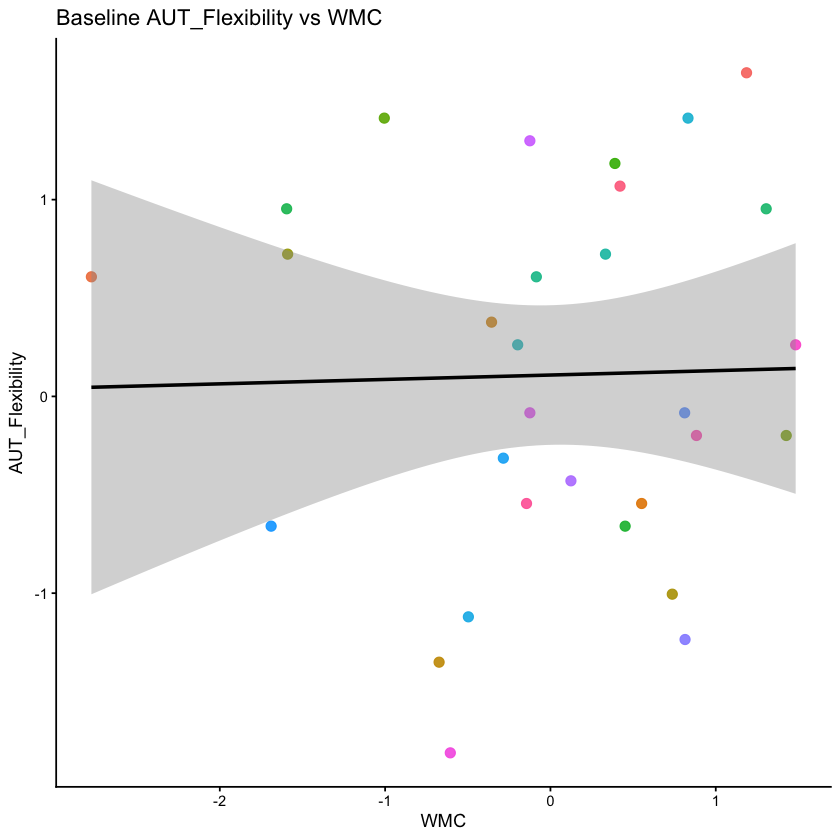

In [17]:
baseline_outcomes <- c(
  "RAT_Accuracy",
  "RAT_Accurate_Insight",
  "RAT_Inaccurate_Insight",
  "RAT_N.A_Insight",
  "AUT_Originality",
  "AUT_Fluency",
  "AUT_Flexibility"
)

baseline_results <- lapply(baseline_outcomes, function(v) run_baseline_analysis(df, v))
names(baseline_results) <- baseline_outcomes
baseline_results

Next we calculate difference scores (i.e. AUT placebo-baseline versus AUT psilocybin-baseline)

In [18]:
# calculate difference scores (from baseline)
library(dplyr)

# 1) Recode missing values
df[df == 999] <- NA

# 2) Dose order
df$Dose <- factor(df$Dose, levels = c("Baseline", "Placebo", "10mg/70kg"))

# 3) Variable groups
id_var     <- "Participant.ID"
design_vars <- c("Dose", "Session")
repeat_vars <- c("EBR", "WMC")   # repeat same value within participant
diff_vars   <- setdiff(names(df), c(id_var, design_vars, repeat_vars))

# 4) Baseline values for difference-score variables
baseline_diff <- df %>%
  filter(Dose == "Baseline") %>%
  select(all_of(c(id_var, diff_vars))) %>%
  rename_with(~ paste0(.x, "_BL"), all_of(diff_vars))

# 5) Baseline values for repeated variables
baseline_repeat <- df %>%
  filter(Dose == "Baseline") %>%
  select(all_of(c(id_var, repeat_vars))) %>%
  rename_with(~ paste0(.x, "_REP"), all_of(repeat_vars))

# 6) Keep only Placebo and 10mg/70kg rows
target <- df %>%
  filter(Dose %in% c("Placebo", "10mg/70kg")) %>%
  select(all_of(c(id_var, "Dose", "Session", diff_vars)))

# 7) Join baseline data
df_diff <- target %>%
  left_join(baseline_diff, by = id_var) %>%
  left_join(baseline_repeat, by = id_var)

# 8) Compute condition - baseline for every difference-score variable
for (v in diff_vars) {
  df_diff[[v]] <- df_diff[[v]] - df_diff[[paste0(v, "_BL")]]
}

# 9) Replace EBR and WMC with repeated baseline values
for (v in repeat_vars) {
  df_diff[[v]] <- df_diff[[paste0(v, "_REP")]]
}

# 10) Keep only final columns
df_diff <- df_diff %>%
  select(all_of(c(id_var, "Dose", "Session", repeat_vars, diff_vars)))

Now we run mixed effects models for each variable of interest. Dose, Session, WMC and EBR being predictors.

In [20]:
library(lme4)
library(lmerTest)
library(ggplot2)
library(dplyr)

run_mixed_model <- function(data, outcome) {
  dat <- data %>%
    select(Participant.ID, Dose, Session, EBR, WMC, all_of(outcome)) %>%
    na.omit()

  colnames(dat)[colnames(dat) == outcome] <- "y"

  model <- lmer(
    y ~ Dose*EBR + Session + WMC + (1 | Participant.ID),
    data = dat,
    REML = FALSE
  )

  p <- ggplot(dat, aes(x = Dose, y = y, group = Participant.ID, color = Participant.ID)) +
    geom_boxplot(
      aes(group = Dose),
      color = "black",
      fill = NA,
      outlier.shape = NA,
      width = 0.5
    ) +
    geom_line(alpha = 0.5, linewidth = 0.6) +
    geom_point(
      size = 2.5,
      alpha = 0.9,
      position = position_jitter(width = 0.05, height = 0)
    ) +
    labs(
      title = paste(outcome, "difference scores by Dose"),
      x = "Dose",
      y = outcome
    ) +
    theme_classic() +
    theme(legend.position = "none")

  list(
    model = model,
    summary = summary(model),
    anova = anova(model),
    plot = p
  )
}

Looking at RAT accuracy, we see that there is a p=0.05 significance for EBR and dose interaction

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: y ~ Dose * EBR + Session + WMC + (1 | Participant.ID)
   Data: dat

      AIC       BIC    logLik -2*log(L)  df.resid 
    158.5     174.9     -71.2     142.5        50 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8147 -0.5765  0.1604  0.4638  2.1139 

Random effects:
 Groups         Name        Variance Std.Dev.
 Participant.ID (Intercept) 0.4708   0.6861  
 Residual                   0.3585   0.5987  
Number of obs: 58, groups:  Participant.ID, 29

Fixed effects:
                  Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)        0.46266    0.18172 51.34487   2.546   0.0139 *
Dose10mg/70kg     -0.32701    0.15992 29.00000  -2.045   0.0500 .
EBR               -0.24109    0.16719 43.43278  -1.442   0.1565  
Session3          -0.07499    0.16082 29.00000  -0.466   0.6445  
WMC               -0.01050    0.15173 29.00000  -0.069   0.9453  
Dos

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Dose,1.498855916,1.498855916,1,29,4.181409028,0.05003987
EBR,2.564207189,2.564207189,1,29,7.153455497,0.01216559
Session,0.077946971,0.077946971,1,29,0.217451301,0.64447277
WMC,0.001717199,0.001717199,1,29,0.004790528,0.94529462
Dose:EBR,1.487684794,1.487684794,1,29,4.150244572,0.05084634


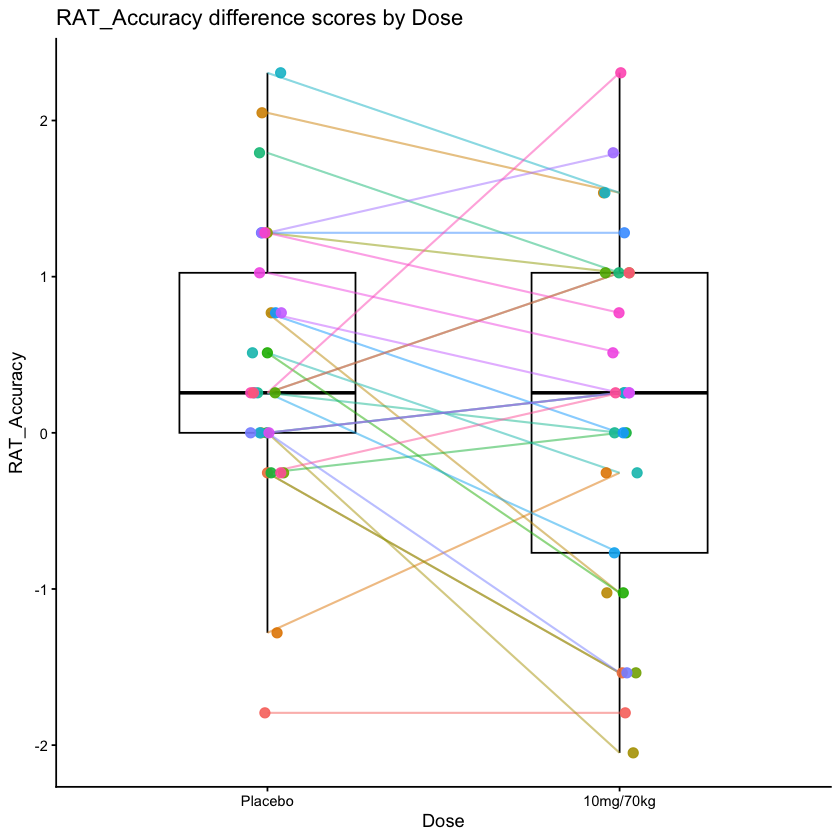

In [21]:
res_rat <- run_mixed_model(df_diff, "RAT_Accuracy")
res_rat$summary
res_rat$anova
print(res_rat$plot)

In [22]:
plot_dose_ebr_interaction <- function(data, outcome, ebr_var = "EBR", id_var = "Participant.ID") {
  
  # Keep only needed columns
  dat <- data %>%
    select(all_of(c(id_var, "Dose", "Session", ebr_var, outcome))) %>%
    na.omit()
  
  # Create participant-level EBR group (Low / High)
  ebr_groups <- dat %>%
    group_by(.data[[id_var]]) %>%
    summarise(EBR_value = first(.data[[ebr_var]]), .groups = "drop") %>%
    mutate(
      EBR_group = ifelse(
        EBR_value <= median(EBR_value, na.rm = TRUE),
        "Low EBR",
        "High EBR"
      )
    )
  
  # Join group back to row-level data
  dat <- dat %>%
    left_join(ebr_groups, by = setNames(id_var, id_var))
  
  # Plot
  p <- ggplot(
    dat,
    aes(
      x = Dose,
      y = .data[[outcome]],
      group = .data[[id_var]],
      color = .data[[id_var]]
    )
  ) +
    geom_boxplot(
      aes(group = Dose),
      color = "black",
      fill = NA,
      outlier.shape = NA,
      width = 0.5
    ) +
    geom_line(alpha = 0.45, linewidth = 0.5) +
    geom_point(
      size = 2.2,
      alpha = 0.9,
      position = position_jitter(width = 0.05, height = 0)
    ) +
    facet_wrap(~ EBR_group) +
    labs(
      title = paste(outcome, "by Dose, grouped by Low vs High EBR"),
      x = "Dose",
      y = outcome
    ) +
    theme_classic() +
    theme(legend.position = "none")
  
  return(p)
}

We plot that interaction here. People with high EBR perform better during placebo compared to psilocybin and vice versa

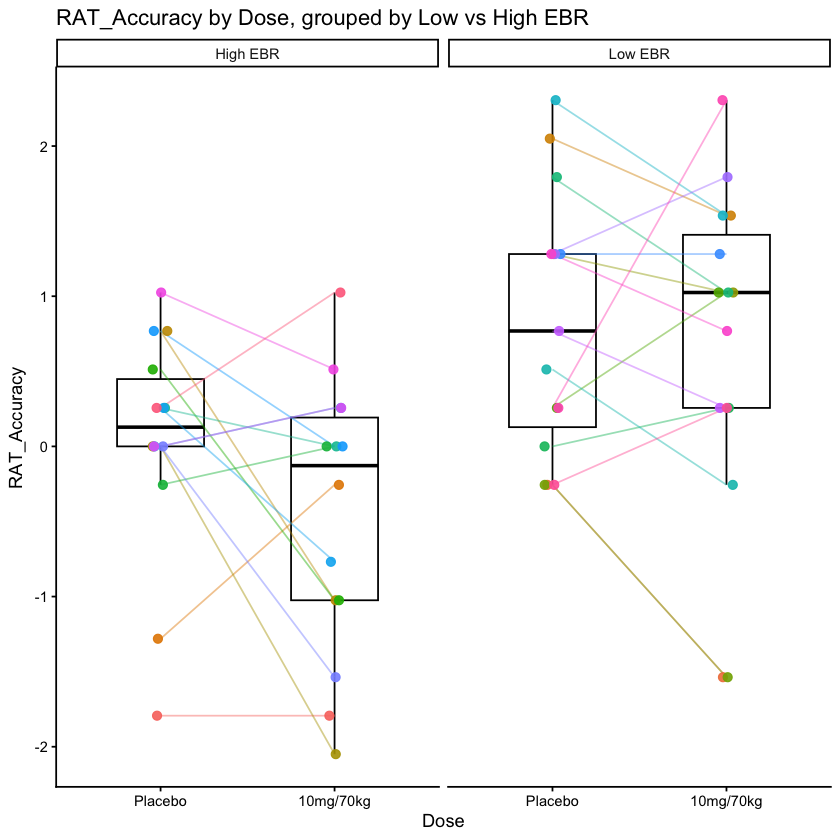

In [24]:
p_rat_acc <- plot_dose_ebr_interaction(df_diff, "RAT_Accuracy")
print(p_rat_acc)

Model results for AUT_originality also show an interaction with EBR

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: y ~ Dose * EBR + Session + WMC + (1 | Participant.ID)
   Data: dat

      AIC       BIC    logLik -2*log(L)  df.resid 
    154.0     170.3     -69.0     138.0        49 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.85717 -0.75632 -0.00551  0.88162  1.82049 

Random effects:
 Groups         Name        Variance Std.Dev.
 Participant.ID (Intercept) 0.05503  0.2346  
 Residual                   0.60616  0.7786  
Number of obs: 57, groups:  Participant.ID, 29

Fixed effects:
                  Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)        0.72431    0.17803 54.54846   4.068 0.000154 ***
Dose10mg/70kg     -0.12051    0.20809 29.29144  -0.579 0.566920    
EBR                0.48036    0.14755 56.54316   3.256 0.001915 ** 
Session3          -0.04563    0.20942 29.32415  -0.218 0.829025    
WMC               -0.02595    0.11744 29.06116  -

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Dose,0.20331146,0.20331146,1,29.29144,0.33540675,0.566920170
EBR,1.07642026,1.07642026,1,28.78245,1.77579086,0.193121361
Session,0.02877793,0.02877793,1,29.32415,0.04747550,0.829024939
WMC,0.02959191,0.02959191,1,29.06116,0.04881834,0.826677410
Dose:EBR,6.90315870,6.90315870,1,28.69593,11.38827149,0.002134683


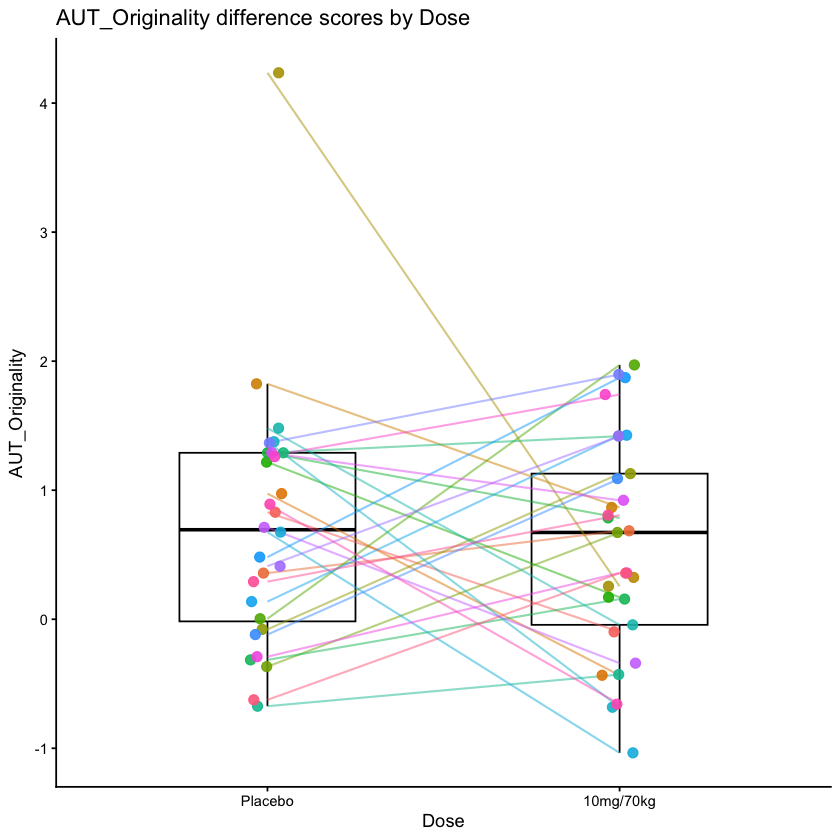

In [25]:
res_rat <- run_mixed_model(df_diff, "AUT_Originality")
res_rat$summary
res_rat$anova
print(res_rat$plot)

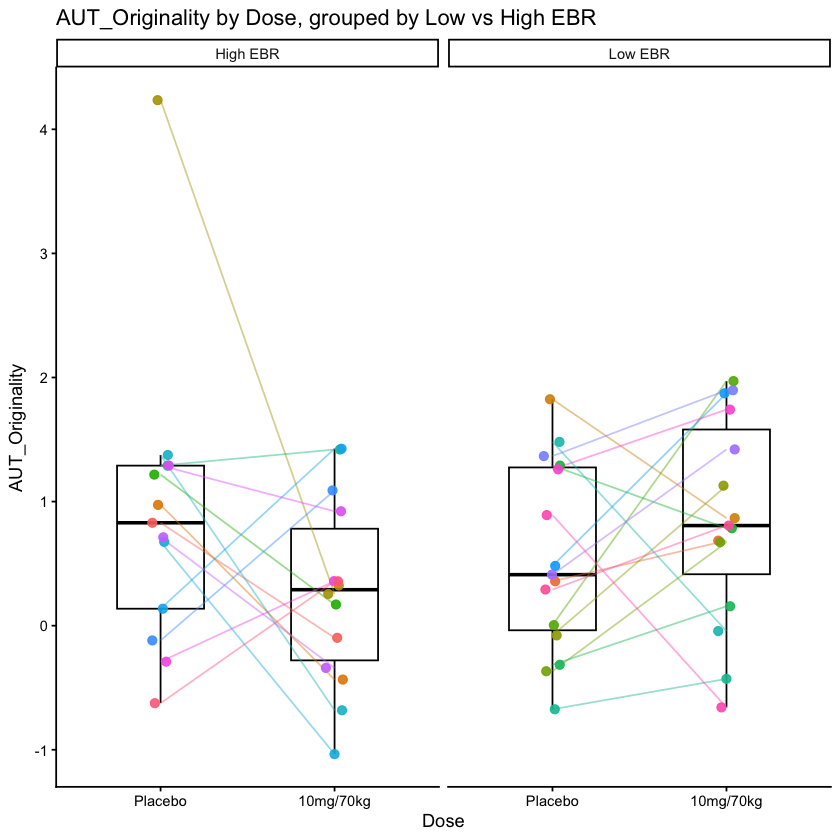

In [26]:
p_aut_flex <- plot_dose_ebr_interaction(df_diff, "AUT_Originality")
print(p_aut_flex)

But note the outlier in there again! We'll get to that

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: y ~ Dose * EBR + Session + WMC + (1 | Participant.ID)
   Data: dat

      AIC       BIC    logLik -2*log(L)  df.resid 
    111.4     127.7     -47.7      95.4        49 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4271 -0.5230 -0.1938  0.4305  2.4978 

Random effects:
 Groups         Name        Variance Std.Dev.
 Participant.ID (Intercept) 0.2504   0.5004  
 Residual                   0.1486   0.3855  
Number of obs: 57, groups:  Participant.ID, 29

Fixed effects:
                  Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)        0.13852    0.12647 49.24884   1.095   0.2787    
Dose10mg/70kg     -0.51219    0.10366 28.50241  -4.941 3.12e-05 ***
EBR                0.18310    0.11485 41.12665   1.594   0.1185    
Session3          -0.07176    0.10436 28.52179  -0.688   0.4972    
WMC               -0.29433    0.11148 28.94902  -2.640   0.

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Dose,3.62801339,3.62801339,1,28.50241,24.4124383,3.119488e-05
EBR,0.13532751,0.13532751,1,28.77413,0.9106015,3.479034e-01
Session,0.07027358,0.07027358,1,28.52179,0.4728619,4.972279e-01
WMC,1.03589747,1.03589747,1,28.94902,6.9704217,1.321168e-02
Dose:EBR,0.43460099,0.43460099,1,28.14391,2.9243745,9.825547e-02


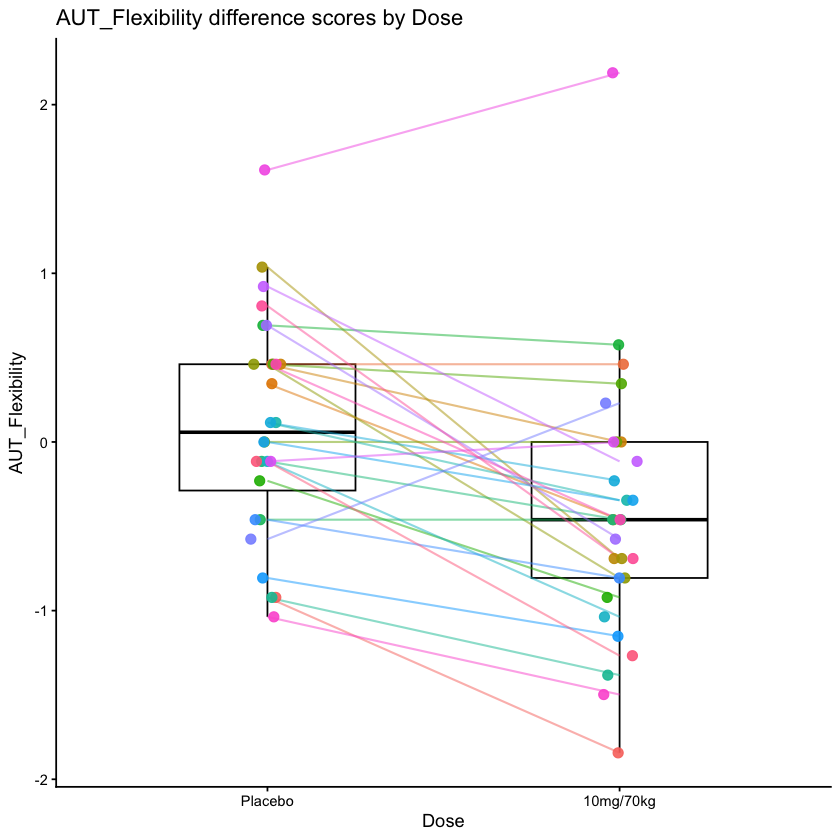

In [27]:
res_rat <- run_mixed_model(df_diff, "AUT_Flexibility")
res_rat$summary
res_rat$anova
print(res_rat$plot)

Flexibility shows a dose relationship, where psilocybin decreases AUT fluency and WMC also decreases it (this doesn't make sense ane may have something to do with covariance with EBR - we should get to that later - specifically because it's similar to fluency see below)

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: y ~ Dose * EBR + Session + WMC + (1 | Participant.ID)
   Data: dat

      AIC       BIC    logLik -2*log(L)  df.resid 
    109.7     125.6     -46.8      93.7        46 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.67961 -0.40894 -0.09317  0.30574  2.34516 

Random effects:
 Groups         Name        Variance Std.Dev.
 Participant.ID (Intercept) 0.1797   0.4239  
 Residual                   0.1963   0.4430  
Number of obs: 54, groups:  Participant.ID, 28

Fixed effects:
                  Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)        0.13956    0.12815 51.47082   1.089 0.281224    
Dose10mg/70kg     -0.46486    0.12464 25.43671  -3.730 0.000968 ***
EBR               -0.12771    0.11419 43.59503  -1.118 0.269534    
Session3           0.08471    0.12577 25.39042   0.674 0.506674    
WMC               -0.25655    0.10507 26.85743  -

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Dose,2.73024574,2.73024574,1,25.43671,13.9093606,0.0009681296
EBR,0.63564900,0.63564900,1,25.47015,3.2383427,0.0837921975
Session,0.08905375,0.08905375,1,25.39042,0.4536884,0.5066743096
WMC,1.17017187,1.17017187,1,26.85743,5.9614936,0.0214937692
Dose:EBR,0.13521355,0.13521355,1,24.58236,0.6888515,0.4145431380


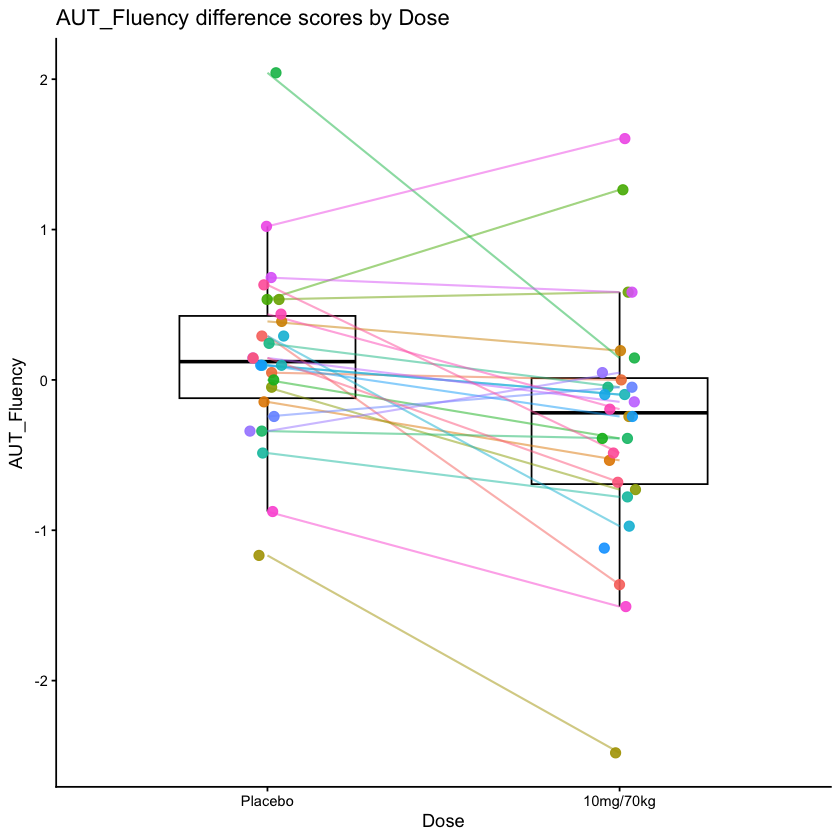

In [28]:
res_rat <- run_mixed_model(df_diff, "AUT_Fluency")
res_rat$summary
res_rat$anova
print(res_rat$plot)

What happens if we remove those outliers again?

In [29]:
model_dat <- df_diff %>%
  select(Participant.ID, Dose, Session, EBR, WMC, AUT_Originality) %>%
  na.omit()

m_diff <- lm(AUT_Originality ~ Dose * EBR + Session + WMC, data = model_dat)

model_dat$cooks_d <- cooks.distance(m_diff)
model_dat$hat <- hatvalues(m_diff)
model_dat$std_resid <- rstandard(m_diff)

cutoff <- 4 / nrow(model_dat)

model_dat %>%
  mutate(influential = cooks_d > cutoff) %>%
  arrange(desc(cooks_d)) %>%
  select(Participant.ID, Dose, AUT_Originality, cooks_d, hat, std_resid, influential)

infl_ids <- model_dat %>%
  mutate(influential = cooks_d > cutoff) %>%
  filter(influential) %>%
  pull(Participant.ID) %>%
  unique()

infl_ids

model_dat_no <- model_dat %>%
  filter(!Participant.ID %in% infl_ids)

m_diff_full <- lm(AUT_Originality ~ Dose * EBR + Session + WMC, data = model_dat)
m_diff_no   <- lm(AUT_Originality ~ Dose * EBR + Session + WMC, data = model_dat_no)

summary(m_diff_full)
summary(m_diff_no)

Participant.ID,Dose,AUT_Originality,cooks_d,hat,std_resid,influential
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
18,Placebo,4.234914011,1.681080e+00,0.56601881,2.78092879,TRUE
18,10mg/70kg,0.255623310,1.596391e-01,0.56369317,0.86103330,TRUE
60,Placebo,-0.118880944,7.176811e-02,0.11181198,-1.84948020,TRUE
87,10mg/70kg,-0.658530154,5.122523e-02,0.09861187,-1.67613464,FALSE
52,10mg/70kg,-1.035376889,4.553046e-02,0.08332707,-1.73356769,FALSE
91,Placebo,-0.624564170,4.491545e-02,0.07140299,-1.87209962,FALSE
57,10mg/70kg,1.872521268,4.222597e-02,0.12766331,1.31575327,FALSE
77,10mg/70kg,1.741342296,4.209474e-02,0.13013998,1.29929829,FALSE
77,Placebo,1.260255127,4.121058e-02,0.13032691,1.28452026,FALSE


[1] 18 60
30 Levels: 5 10 12 16 17 18 19 21 30 33 35 36 40 42 45 46 47 52 53 57 60 ... 91


Call:
lm(formula = AUT_Originality ~ Dose * EBR + Session + WMC, data = model_dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.55090 -0.62636  0.02981  0.63041  1.57495 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        0.72471    0.19054   3.804 0.000383 ***
Dose10mg/70kg     -0.12140    0.22955  -0.529 0.599201    
EBR                0.48059    0.15594   3.082 0.003313 ** 
Session3          -0.04471    0.23102  -0.194 0.847293    
WMC               -0.02628    0.11935  -0.220 0.826592    
Dose10mg/70kg:EBR -0.67054    0.21932  -3.057 0.003550 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8597 on 51 degrees of freedom
Multiple R-squared:  0.187,	Adjusted R-squared:  0.1073 
F-statistic: 2.346 on 5 and 51 DF,  p-value: 0.05421



Call:
lm(formula = AUT_Originality ~ Dose * EBR + Session + WMC, data = model_dat_no)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.50805 -0.60678  0.00658  0.69258  1.48012 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)        0.67207    0.19196   3.501  0.00103 **
Dose10mg/70kg     -0.14550    0.22568  -0.645  0.52224   
EBR                0.11363    0.23260   0.489  0.62745   
Session3          -0.08943    0.21885  -0.409  0.68467   
WMC               -0.03109    0.11053  -0.281  0.77972   
Dose10mg/70kg:EBR -0.59339    0.32859  -1.806  0.07734 . 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7909 on 47 degrees of freedom
Multiple R-squared:  0.0915,	Adjusted R-squared:  -0.005144 
F-statistic: 0.9468 on 5 and 47 DF,  p-value: 0.4599


Aha the effect is mostly gone althought still trending - see the comparison plots

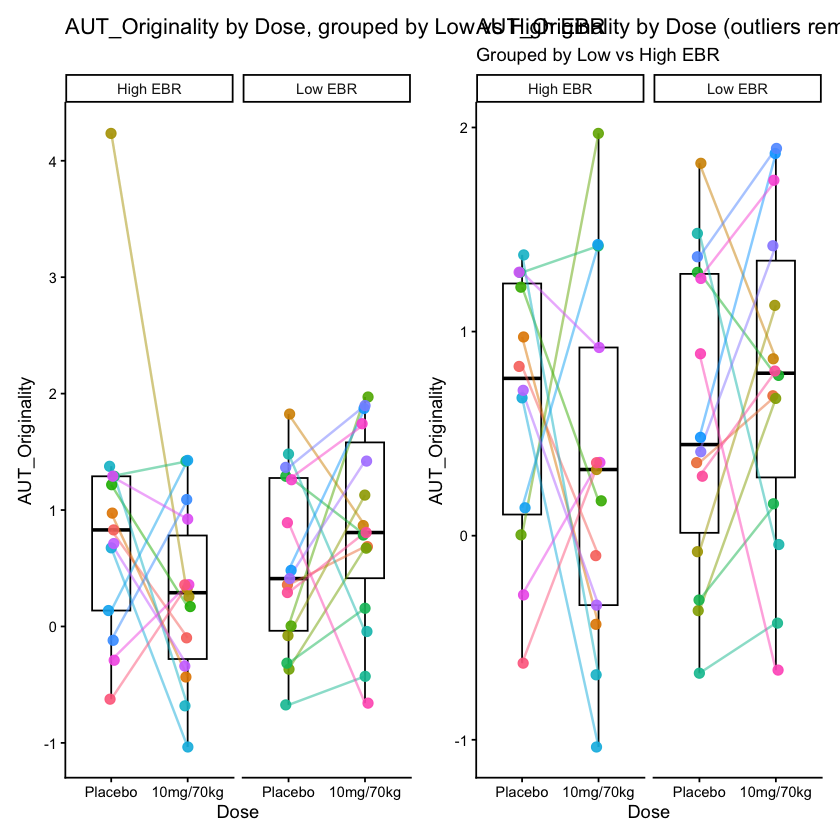

In [30]:
df_diff_no <- df_diff %>%
  filter(!Participant.ID %in% infl_ids)

library(dplyr)
library(ggplot2)

plot_dose_by_ebr_group_clean <- function(data, outcome, id_var = "Participant.ID", ebr_var = "EBR") {
  
  dat <- data %>%
    select(all_of(c(id_var, "Dose", "Session", ebr_var, "WMC", outcome))) %>%
    na.omit()
  
  # Median split on EBR (participant-level)
  ebr_groups <- dat %>%
    group_by(.data[[id_var]]) %>%
    summarise(EBR_value = first(.data[[ebr_var]]), .groups = "drop") %>%
    mutate(
      EBR_group = ifelse(
        EBR_value <= median(EBR_value, na.rm = TRUE),
        "Low EBR",
        "High EBR"
      )
    )
  
  dat <- dat %>%
    left_join(ebr_groups, by = setNames(id_var, id_var))
  
  ggplot(
    dat,
    aes(
      x = Dose,
      y = .data[[outcome]],
      group = .data[[id_var]],
      color = .data[[id_var]]
    )
  ) +
    geom_boxplot(
      aes(group = Dose),
      color = "black",
      fill = NA,
      outlier.shape = NA,
      width = 0.5
    ) +
    geom_line(alpha = 0.5, linewidth = 0.7) +
    geom_point(
      size = 2.5,
      alpha = 0.9,
      position = position_jitter(width = 0.04, height = 0)
    ) +
    facet_wrap(~ EBR_group) +
    labs(
      title = paste(outcome, "by Dose (outliers removed)"),
      subtitle = "Grouped by Low vs High EBR",
      x = "Dose",
      y = outcome
    ) +
    theme_classic() +
    theme(legend.position = "none")
}

p_full  <- plot_dose_by_ebr_group(df_diff, "AUT_Originality")
p_clean <- plot_dose_by_ebr_group_clean(df_diff_no, "AUT_Originality")

library(patchwork)
p_full + p_clean